
# ML-Based Portfolio Stress Testing Framework

## Why I built this

Most portfolio analysis focuses on returns and volatility, but real investing is driven by extreme events.

I built this project to understand:
- how portfolios behave under stress
- whether diversification actually works in crises
- how downside risk changes across regimes
- whether ML can help detect stress environments

---

## What this notebook does

- builds multiple portfolio types  
- evaluates risk metrics  
- tests historical crises  
- simulates scenarios  
- ranks portfolios  
- applies ML for stress detection  

---

## Key idea

> Not “best returns” — but “best survival across regimes”


In [20]:

!pip -q install yfinance scikit-learn


In [21]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

pd.set_option("display.max_columns", 200)


## Data Download

In [22]:

tickers = ["SPY","QQQ","TLT","IEF","GLD","USO","HYG","DBC","SHY"]
prices = yf.download(tickers, start="2007-01-01", auto_adjust=True)["Close"]
returns = prices.pct_change().dropna()


[*********************100%***********************]  9 of 9 completed



## Portfolio Design Logic

Portfolios represent different investor styles and macro positioning.


In [23]:

portfolio_weights = {
    "Conservative":{"SPY":0.1,"QQQ":0.05,"TLT":0.25,"IEF":0.25,"GLD":0.15,"HYG":0.05,"DBC":0.05,"SHY":0.1},
    "Balanced":{"SPY":0.3,"QQQ":0.1,"TLT":0.2,"IEF":0.15,"GLD":0.1,"HYG":0.1,"SHY":0.05},
    "Aggressive":{"SPY":0.35,"QQQ":0.3,"TLT":0.05,"IEF":0.05,"GLD":0.05,"HYG":0.1,"DBC":0.05,"SHY":0.05},
    "Inflation_Hedge":{"SPY":0.15,"QQQ":0.05,"TLT":0.05,"IEF":0.1,"GLD":0.2,"USO":0.15,"DBC":0.2,"SHY":0.05},
    "Recession_Defense":{"SPY":0.1,"QQQ":0.05,"TLT":0.3,"IEF":0.2,"GLD":0.15,"SHY":0.15},
    "All_Weather":{"SPY":0.2,"QQQ":0.05,"TLT":0.2,"IEF":0.15,"GLD":0.15,"HYG":0.1,"DBC":0.1,"SHY":0.05},
    "Concentrated_Equity":{"SPY":0.4,"QQQ":0.4,"GLD":0.05,"SHY":0.15},
    "Custom_100K":{"SPY":0.25,"QQQ":0.15,"TLT":0.15,"IEF":0.1,"GLD":0.1,"HYG":0.1,"DBC":0.05,"USO":0.05,"SHY":0.05}
}

def compute_portfolio_returns(asset_returns, weights):
    w=pd.Series(weights).reindex(asset_returns.columns).fillna(0)
    return (asset_returns*w).sum(axis=1)

portfolio_returns=pd.DataFrame({k:compute_portfolio_returns(returns,v) for k,v in portfolio_weights.items()})


## Growth of $100

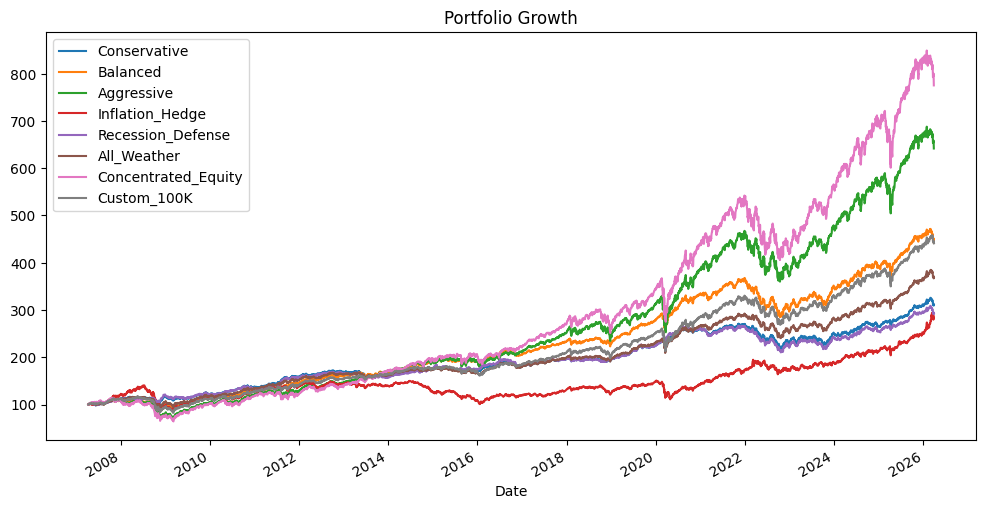

In [24]:

growth=(1+portfolio_returns).cumprod()*100
growth.plot(figsize=(12,6))
plt.title("Portfolio Growth")
plt.show()



## Risk Metrics

Baseline evaluation using standard metrics.


In [25]:

def ann_return(x): return (1+x).prod()**(252/len(x))-1
def ann_vol(x): return x.std()*np.sqrt(252)
def sharpe(x): return ann_return(x)/ann_vol(x)
def mdd(x): return ((1+x).cumprod()/((1+x).cumprod().cummax())-1).min()

risk_table=pd.DataFrame({
    "Return":portfolio_returns.apply(ann_return),
    "Vol":portfolio_returns.apply(ann_vol),
    "Sharpe":portfolio_returns.apply(sharpe),
    "MDD":portfolio_returns.apply(mdd)
})
risk_table


,Return,Vol,Sharpe,MDD
Conservative,0.061600,0.069530,0.885959,-0.197508
Balanced,0.081739,0.089679,0.911458,-0.224665
Aggressive,0.103173,0.142913,0.721925,-0.394983
Inflation_Hedge,0.057203,0.123064,0.464823,-0.381187
Recession_Defense,0.058156,0.069559,0.836067,-0.211036
All_Weather,0.071182,0.078944,0.901676,-0.205328
Concentrated_Equity,0.114242,0.165232,0.691404,-0.438311
Custom_100K,0.081532,0.101551,0.802870,-0.291983



## Historical Stress Testing


In [26]:

windows={
    "GFC":("2007-10-01","2009-03-31"),
    "COVID":("2020-02-01","2020-04-30")
}

records=[]
for name,(s,e) in windows.items():
    sample=portfolio_returns.loc[s:e]
    for col in sample.columns:
        records.append([name,col,(1+sample[col]).prod()-1])
crisis=pd.DataFrame(records,columns=["Window","Portfolio","Return"])
crisis


,Window,Portfolio,Return
0,GFC,Conservative,0.069939
1,GFC,Balanced,-0.112349
2,GFC,Aggressive,-0.291946
3,GFC,Inflation_Hedge,-0.149386
4,GFC,Recession_Defense,0.103905
5,GFC,All_Weather,-0.049420
6,GFC,Concentrated_Equity,-0.334310
7,GFC,Custom_100K,-0.167255
8,COVID,Conservative,0.048308
9,COVID,Balanced,0.025977



## Scenario Testing


In [27]:

scenarios={
    "Crash":{"SPY":-0.2,"QQQ":-0.25},
    "Inflation":{"TLT":-0.15,"GLD":0.05}
}

rows=[]
for p,w in portfolio_weights.items():
    w=pd.Series(w)
    for s,shock in scenarios.items():
        shock_vec=pd.Series(shock)
        r=(w*shock_vec).sum()
        rows.append([p,s,r])
scenario=pd.DataFrame(rows,columns=["Portfolio","Scenario","Return"])
scenario


,Portfolio,Scenario,Return
0,Conservative,Crash,-0.0325
1,Conservative,Inflation,-0.0300
2,Balanced,Crash,-0.0850
3,Balanced,Inflation,-0.0250
4,Aggressive,Crash,-0.1450
5,Aggressive,Inflation,-0.0050
6,Inflation_Hedge,Crash,-0.0425
7,Inflation_Hedge,Inflation,0.0025
8,Recession_Defense,Crash,-0.0325
9,Recession_Defense,Inflation,-0.0375



## ML Stress Detection


In [28]:
base = portfolio_returns["Custom_100K"]
X = pd.DataFrame({
    "ret": base,
    "vol": base.rolling(20).std()
}).dropna()

forward_20d_return = base.shift(-20).loc[X.index]
threshold = forward_20d_return.quantile(0.10)
y = (forward_20d_return < threshold).astype(int).rename("stress_flag")

# Print class distribution
print("Class distribution of stress_flag:")
print(y.value_counts())
print("Stress rate:", y.mean())

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = LogisticRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Class distribution of stress_flag:
stress_flag
0    4278
1     474
Name: count, dtype: int64
Stress rate: 0.09974747474747475
Accuracy: 0.8801261829652997



## Final Takeaway

This project shows:

- performance depends on regime  
- diversification breaks in crises  
- downside risk matters more than average return  

> Portfolio design is about survival, not just returns.
